# ENERGIZE - Data Preparation & Training (PyTorch)

This notebook covers:
1. **Data Preparation**: Loading and preprocessing NILM datasets (REFIT/PLEGMA)
2. **Model Configuration**: Setting up CNN, GRU, or TCN models
3. **Training**: Training the model with early stopping and checkpointing
4. **Visualization**: Training curves and model analysis

---

## Google Colab Setup

**If running on Colab:**
1. Upload your  folder to Google Drive (e.g., `My Drive/ENERGIZE/`)
2. Run the Colab setup cells below first
3. Edit `DRIVE_PROJECT_PATH` to match your folder location

---

In [ ]:
# ============================================================================
# COLAB SETUP - Run this cell first!
# ============================================================================
import sys

# Detect if running on Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')


    # =========================================================================
    # CONFIGURE YOUR GOOGLE DRIVE PATH HERE
    # =========================================================================
    DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL'  # <-- EDIT THIS PATH
    # =========================================================================

    import os
    from pathlib import Path

    project_root = Path(DRIVE_PROJECT_PATH)

    if not project_root.exists():
        print(f"ERROR: Project folder not found at: {project_root}")
        print(f"Please upload OpenNILM to Google Drive or edit DRIVE_PROJECT_PATH above")
        print(f"\nYour Drive contents:")
        !ls "/content/drive/MyDrive/" | head -15
    else:
        os.chdir(project_root)
        sys.path.insert(0, str(project_root))
        print(f"Project root: {project_root}")
        print(f"Working directory: {os.getcwd()}")
else:
    import os
    from pathlib import Path
    project_root = Path(os.getcwd()).parent
    sys.path.insert(0, str(project_root))
    print(f"Running locally. Project root: {project_root}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL
Working directory: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL


## 1. Setup and Imports

In [ ]:
# ============================================================================
# IMPORTS (os, sys, Path, project_root already defined in Colab setup cell)
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# PyTorch NILM modules
from src_pytorch import (
    CNN_NILM, TCN_NILM,get_model,
    SimpleNILMDataLoader,
    Trainer, EarlyStopping, ModelCheckpoint, TrainingHistory,
    set_seeds, get_device, count_parameters, print_model_summary,
    # Config
    MODEL_CONFIGS, get_appliance_params, get_model_config
)
from src_pytorch.config import get_training_config
from src_pytorch.models.cnn_seq2seq import CNN_NILM_Seq2Seq

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Set seeds for reproducibility
set_seeds(42)

# Get device
device = get_device()

Seeds set to 42
Using GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 85.09 GB


## 2. Configuration

Configure the experiment parameters below:

In [ ]:
# ============================================================================
# USER CONFIGURATION - Modify these values only
# ============================================================================
DATASET_NAME   = 'plegma'   # 'refit' or 'plegma'
APPLIANCE_NAME = 'boiler'
                             # PLEGMA: ac_1, boiler, washing_machine, fridge
MODEL_NAME     = 'wavenet_tcn'      # 'cnn', 'cnn_seq2seq', or 'wavenet_tcn'


# ============================================================================
# AUTO-LOADED FROM CONFIG (src_pytorch/config.py) - Don't modify below
# ============================================================================
# Architecture parameters
model_config        = get_model_config(MODEL_NAME)
INPUT_WINDOW_LENGTH = model_config['input_window_length']
BATCH_SIZE          = model_config['batch_size']

# Training parameters — model-specific values defined in config.py
training_config          = get_training_config(MODEL_NAME)
EPOCHS                   = training_config['epochs']
LEARNING_RATE            = training_config['learning_rate']
EARLY_STOPPING_PATIENCE  = training_config['early_stopping_patience']
EARLY_STOPPING_MIN_DELTA = training_config['early_stopping_min_delta']
LR_SCHEDULER_FACTOR      = training_config['lr_scheduler']['factor']
LR_SCHEDULER_PATIENCE    = training_config['lr_scheduler']['patience']
LR_SCHEDULER_MIN_LR      = training_config['lr_scheduler']['min_lr']
LR_SCHEDULER_COOLDOWN    = training_config['lr_scheduler']['cooldown']

# Appliance parameters
appliance_params = get_appliance_params(DATASET_NAME, APPLIANCE_NAME)
THRESHOLD = appliance_params['threshold']
CUTOFF    = appliance_params['cutoff']
AGG_MEAN  = appliance_params['mean']
AGG_STD   = appliance_params['std']

# Paths
DATA_DIR   = Path('/content/drive/MyDrive/Colab Notebooks/ENERGIZE') / 'data' / 'processed' / DATASET_NAME / APPLIANCE_NAME
OUTPUT_DIR = project_root / 'outputs' / f'{MODEL_NAME}_{APPLIANCE_NAME}'

# Create output directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'checkpoint').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tensorboard').mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)

# Print configuration summary
print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Dataset:           {DATASET_NAME}")
print(f"Appliance:         {APPLIANCE_NAME}")
print(f"Model:             {MODEL_NAME}")
print(f"Window length:     {INPUT_WINDOW_LENGTH}")
print(f"Batch size:        {BATCH_SIZE}")
print(f"Epochs:            {EPOCHS}")
print(f"Learning rate:     {LEARNING_RATE}")
print(f"Early stopping:    patience={EARLY_STOPPING_PATIENCE}, min_delta={EARLY_STOPPING_MIN_DELTA}")
print(f"LR scheduler:      factor={LR_SCHEDULER_FACTOR}, patience={LR_SCHEDULER_PATIENCE}, min_lr={LR_SCHEDULER_MIN_LR}, cooldown={LR_SCHEDULER_COOLDOWN}")
print(f"Threshold:         {THRESHOLD} W")
print(f"Cutoff:            {CUTOFF} W")
print(f"Data directory:    {DATA_DIR}")
print(f"Output directory:  {OUTPUT_DIR}")
print("=" * 60)

CONFIGURATION
Dataset:           plegma
Appliance:         boiler
Model:             tcn
Window length:     600
Batch size:        128
Epochs:            50
Learning rate:     0.0001
Early stopping:    patience=10, min_delta=1e-06
LR scheduler:      factor=0.5, patience=3, min_lr=1e-06, cooldown=2
Threshold:         800 W
Cutoff:            4000 W
Data directory:    /content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/boiler
Output directory:  /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler


In [ ]:
# TCN
EPOCHS                   = 100
LEARNING_RATE            = 0.001
EARLY_STOPPING_PATIENCE  = 40
EARLY_STOPPING_MIN_DELTA = training_config['early_stopping_min_delta']
LR_SCHEDULER_FACTOR      = training_config['lr_scheduler']['factor']
LR_SCHEDULER_PATIENCE    = 7
LR_SCHEDULER_MIN_LR      = training_config['lr_scheduler']['min_lr']
LR_SCHEDULER_COOLDOWN    = training_config['lr_scheduler']['cooldown']


## 3. Data Preparation

### 3.1 Load Raw Data (Optional - For Data Exploration)

If you need to process raw data first, run the data processing script:
```bash
cd data
python data.py dataset=refit appliance=dishwasher
```

In [ ]:
# Check if processed data exists
if not DATA_DIR.exists():
    print(f"Warning: Data directory does not exist: {DATA_DIR}")
    print("Please run the data processing script first.")
else:
    print(f"Data directory found: {DATA_DIR}")
    print(f"Files: {list(DATA_DIR.glob('*.csv'))}")

Data directory found: /content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/boiler
Files: [PosixPath('/content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/boiler/training_.csv'), PosixPath('/content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/boiler/validation_.csv'), PosixPath('/content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/boiler/test_.csv')]


### 3.2 Explore the Processed Data

In [ ]:
# Load and explore the training data
train_df = pd.read_csv(DATA_DIR / 'training_.csv')
val_df = pd.read_csv(DATA_DIR / 'validation_.csv')
test_df = pd.read_csv(DATA_DIR / 'test_.csv')

print("Training data shape:", train_df.shape)
print("Validation data shape:", val_df.shape)
print("Test data shape:", test_df.shape)
print("\nColumn names:", train_df.columns.tolist())
print("\nTraining data statistics:")
train_df.describe()

Training data shape: (23724021, 2)
Validation data shape: (1284649, 2)
Test data shape: (1627136, 2)

Column names: ['aggregate', 'boiler']

Training data statistics:


,aggregate,boiler
count,2.372402e+07,2.372402e+07
mean,6.032240e-17,1.426890e-02
std,1.000000e+00,1.009933e-01
min,-4.664398e-01,0.000000e+00
25%,-3.851159e-01,0.000000e+00
50%,-2.993690e-01,0.000000e+00
75%,-1.719684e-01,0.000000e+00
max,1.295291e+01,9.496360e-01


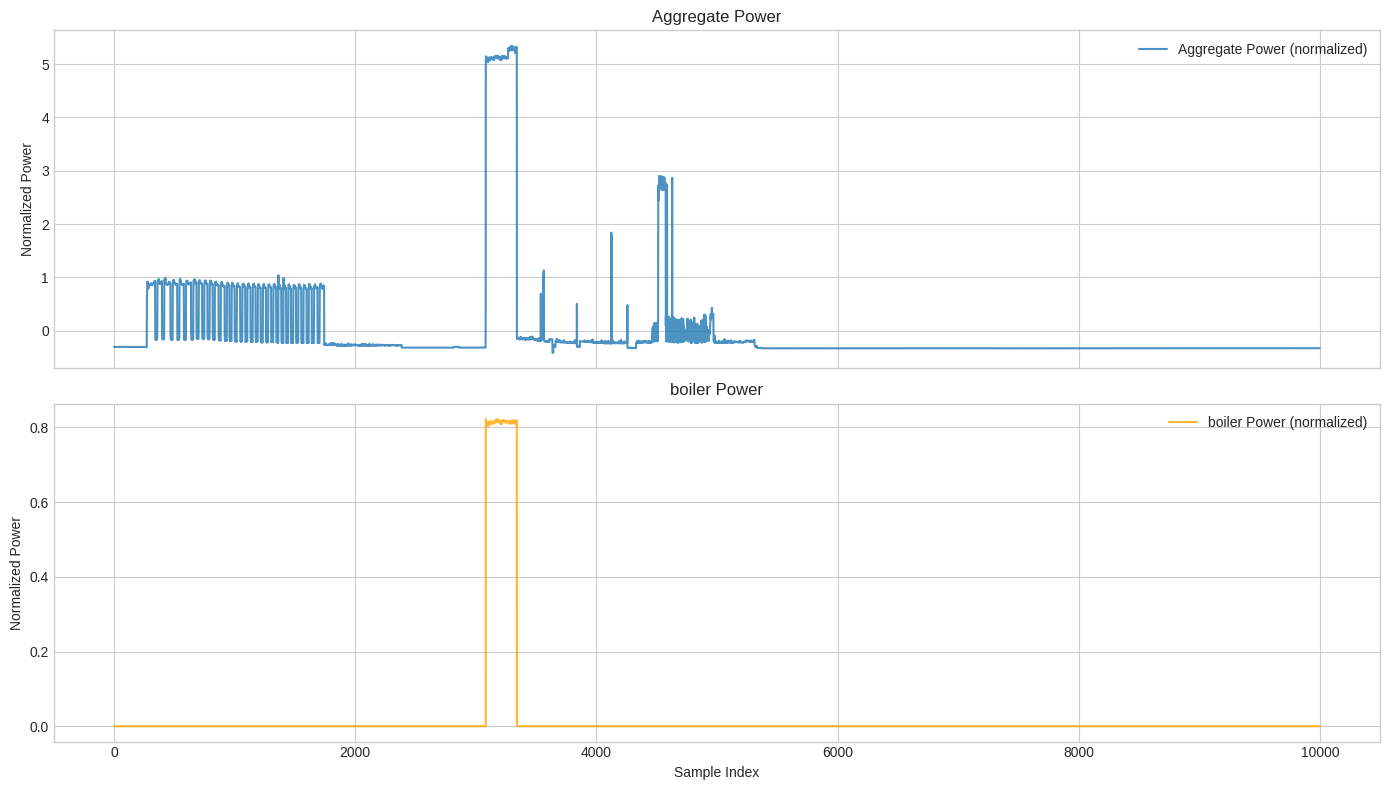

In [ ]:
# Visualize a sample of the data
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sample_size = min(10000, len(train_df))
sample = train_df.iloc[:sample_size]

axes[0].plot(sample.iloc[:, 0], label='Aggregate Power (normalized)', alpha=0.8)
axes[0].set_ylabel('Normalized Power')
axes[0].set_title('Aggregate Power')
axes[0].legend()

axes[1].plot(sample.iloc[:, 1], label=f'{APPLIANCE_NAME} Power (normalized)', alpha=0.8, color='orange')
axes[1].set_ylabel('Normalized Power')
axes[1].set_xlabel('Sample Index')
axes[1].set_title(f'{APPLIANCE_NAME} Power')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'data_visualization.png', dpi=150)
plt.show()

### 3.3 Create Data Loaders

In [ ]:
# Create data loader
data_loader = SimpleNILMDataLoader(
    data_dir=str(DATA_DIR),
    model_name=MODEL_NAME,
    batch_size=BATCH_SIZE,
    input_window_length=INPUT_WINDOW_LENGTH,
    train=True,
    num_workers=0  # Set to > 0 for parallel data loading
)

# Get data loaders
train_loader = data_loader.train
val_loader = data_loader.val
test_loader = data_loader.test

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Check a batch
batch_x, batch_y = next(iter(train_loader))
print(f"\nBatch X shape: {batch_x.shape}")
print(f"Batch Y shape: {batch_y.shape}")

Training batches: 308
Validation batches: 17
Test batches: 22

Batch X shape: torch.Size([128, 600, 1])
Batch Y shape: torch.Size([128, 600, 1])


## 4. Model Setup

In [1]:
# Create the model
if MODEL_NAME == 'cnn':
    model = CNN_NILM(input_window_length=INPUT_WINDOW_LENGTH)
elif MODEL_NAME == 'wavenet_tcn':
    model = TCN_NILM(
        input_window_length=INPUT_WINDOW_LENGTH,
        depth=model_config.get('depth', 9),
        nb_filters=[512, 360, 360, 256, 256, 256, 360, 360, 512],
        dropout=model_config.get('dropout', 0.1),
        stacks=1
    )
elif MODEL_NAME == 'cnn_seq2seq':
    model = CNN_NILM_Seq2Seq(input_window_length=INPUT_WINDOW_LENGTH)

# Move model to device
model = model.to(device)

# Print model summary
n_params = count_parameters(model)
model_size_mb = n_params * 4 / 1024**2  # FP32: 4 bytes per parameter

print(f"\nModel: {MODEL_NAME.upper()}")
print(f"Trainable parameters: {n_params:,}")
print(f"Model size (FP32):    {model_size_mb:.1f} MB")
print(f"Model size (INT8):    {model_size_mb / 4:.1f} MB")
print("\nModel architecture:")
print(model)

NameError: name 'MODEL_NAME' is not defined

In [ ]:
# Test forward pass
with torch.no_grad():
    test_input = batch_x[:2].to(device)
    test_output = model(test_input)
    print(f"Test input shape: {test_input.shape}")
    print(f"Test output shape: {test_output.shape}")

Test input shape: torch.Size([2, 600, 1])
Test output shape: torch.Size([2, 600, 1])


## 5. Training

In [ ]:
# Setup optimizer and loss
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    eps=1e-8
)

loss_fn = nn.MSELoss()

# Create trainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device
)

# Setup callbacks
trainer.setup_callbacks(
    checkpoint_dir=str(OUTPUT_DIR / 'checkpoint'),
    tensorboard_dir=str(OUTPUT_DIR / 'tensorboard'),
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=1e-6,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    lr_scheduler_min_lr=LR_SCHEDULER_MIN_LR,
    lr_scheduler_cooldown=LR_SCHEDULER_COOLDOWN,
)

print("Trainer configured successfully!")
print(f"Checkpoint will be saved to: {OUTPUT_DIR / 'checkpoint' / 'model.pt'}")
print(f"TensorBoard logs will be saved to: {OUTPUT_DIR / 'tensorboard'}")

Trainer configured successfully!
Checkpoint will be saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/checkpoint/model.pt
TensorBoard logs will be saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/tensorboard


In [ ]:
# Train the model
print(f"\nStarting training for {EPOCHS} epochs...")
print("=" * 60)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    verbose=True
)

print("\nTraining completed!")


Starting training for 100 epochs...


Epoch 1: 100%|██████████| 308/308 [00:28<00:00, 10.87it/s, loss=0.0159, lr=1.00e-03]


Epoch 1/100 - loss: 0.3546 - val_loss: 0.0061 - mae: 0.2054 - val_mae: 0.0529 - lr: 1.00e-03
Model saved to /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/checkpoint/model.pt and /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/checkpoint/model.pth (val_loss: 0.006139)


Epoch 2: 100%|██████████| 308/308 [00:28<00:00, 10.88it/s, loss=0.00396, lr=1.00e-03]


Epoch 2/100 - loss: 0.0082 - val_loss: 0.0057 - mae: 0.0562 - val_mae: 0.0631 - lr: 1.00e-03
Model saved to /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/checkpoint/model.pt and /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/checkpoint/model.pth (val_loss: 0.005657)


...

ReduceLROnPlateau: LR reduced from 6.25e-05 to 3.13e-05
Epoch 85/100 - loss: 0.0003 - val_loss: 0.0002 - mae: 0.0016 - val_mae: 0.0006 - lr: 3.13e-05
EarlyStopping: 38/40


Epoch 86: 100%|██████████| 308/308 [00:28<00:00, 10.85it/s, loss=0.000156, lr=3.13e-05]


Epoch 86/100 - loss: 0.0003 - val_loss: 0.0002 - mae: 0.0015 - val_mae: 0.0006 - lr: 3.13e-05
EarlyStopping: 39/40


Epoch 87: 100%|██████████| 308/308 [00:28<00:00, 10.85it/s, loss=0.000295, lr=3.13e-05]


Epoch 87/100 - loss: 0.0003 - val_loss: 0.0002 - mae: 0.0015 - val_mae: 0.0005 - lr: 3.13e-05
EarlyStopping: 40/40
Early stopping triggered!

Early stopping at epoch 87

Best epoch: 47 | Best val_loss: 0.000134
Final model saved to /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/checkpoint/model_final.pt and /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/checkpoint/model_final.pth

Training completed!


## 6. Training Analysis

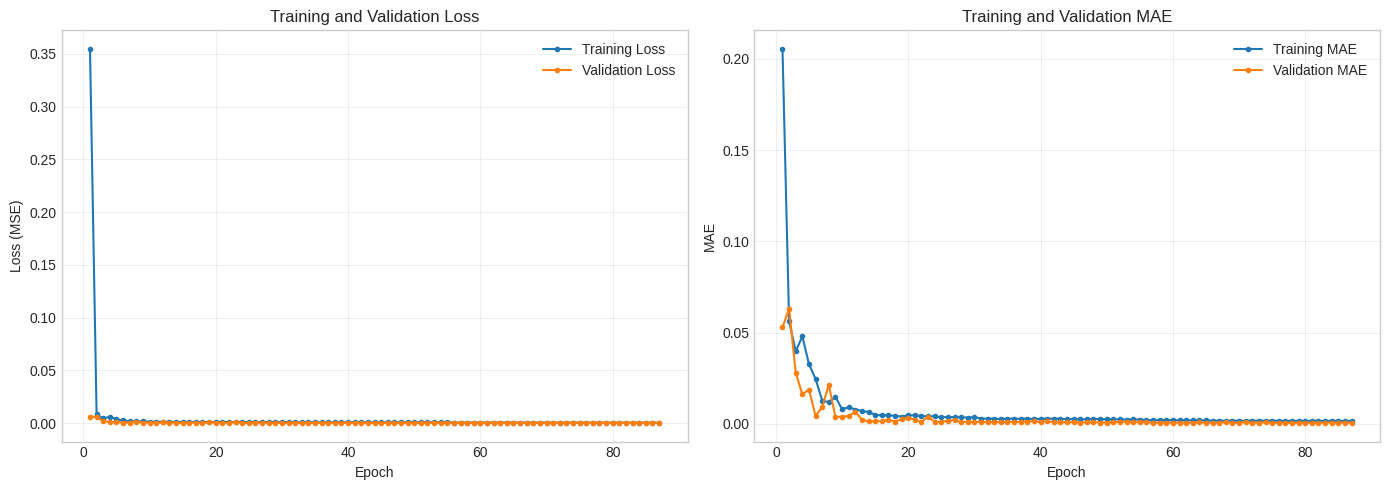


Best epoch: 47
Best validation loss: 0.000134
Best validation MAE: 0.000693


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.epochs, history.train_loss, label='Training Loss', marker='o', markersize=3)
axes[0].plot(history.epochs, history.val_loss, label='Validation Loss', marker='o', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
if history.train_mae:
    axes[1].plot(history.epochs, history.train_mae, label='Training MAE', marker='o', markersize=3)
    axes[1].plot(history.epochs, history.val_mae, label='Validation MAE', marker='o', markersize=3)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].set_title('Training and Validation MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'training_curves.png', dpi=150)
plt.show()

# Print best results
best_epoch = np.argmin(history.val_loss)
print(f"\nBest epoch: {best_epoch + 1}")
print(f"Best validation loss: {history.val_loss[best_epoch]:.6f}")
print(f"Best validation MAE: {history.val_mae[best_epoch]:.6f}" if history.val_mae else "")

In [ ]:
# Save training history
history_df = pd.DataFrame({
    'epoch': history.epochs,
    'train_loss': history.train_loss,
    'val_loss': history.val_loss,
    'train_mae': history.train_mae,
    'val_mae': history.val_mae
})
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print(f"Training history saved to: {OUTPUT_DIR / 'training_history.csv'}")

Training history saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/tcn_boiler/training_history.csv


## 7. Load Best Model and Quick Evaluation

In [ ]:
# Load the best model checkpoint
checkpoint_path = OUTPUT_DIR / 'checkpoint' / 'model.pt'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

print(f"Loaded best model from: {checkpoint_path}")

Loaded best model from: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pt


In [ ]:
# Quick evaluation on validation set
@torch.no_grad()
def quick_evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0
    total_mae = 0
    num_batches = 0

    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)

        if outputs.shape != batch_y.shape:
            if outputs.dim() == 2 and batch_y.dim() == 1:
                batch_y = batch_y.unsqueeze(1)

        loss = nn.MSELoss()(outputs, batch_y)
        mae = torch.mean(torch.abs(outputs - batch_y))

        total_loss += loss.item()
        total_mae += mae.item()
        num_batches += 1

    return total_loss / num_batches, total_mae / num_batches

val_loss, val_mae = quick_evaluate(model, val_loader, device)
test_loss, test_mae = quick_evaluate(model, test_loader, device)

print(f"Validation - Loss: {val_loss:.6f}, MAE: {val_mae:.6f}")
print(f"Test - Loss: {test_loss:.6f}, MAE: {test_mae:.6f}")

Validation - Loss: 0.005831, MAE: 0.015765
Test - Loss: 0.001209, MAE: 0.006786


## 8. Summary

Training is complete! The model has been saved to the checkpoint directory.

**Next Steps:**
1. Open `02_evaluation.ipynb` for detailed evaluation and visualization
2. Launch TensorBoard to view training logs:
   ```bash
   tensorboard --logdir outputs/{model}_{appliance}/tensorboard
   ```

In [ ]:
# Print summary
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Appliance: {APPLIANCE_NAME}")
print(f"Dataset: {DATASET_NAME}")
print(f"Total parameters: {count_parameters(model):,}")
print(f"Epochs trained: {len(history.epochs)}")
print(f"Best validation loss: {min(history.val_loss):.6f}")
print(f"Test loss: {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")
print(f"\nCheckpoint saved to: {checkpoint_path}")
print("=" * 60)

TRAINING SUMMARY
Model: tcn
Appliance: ac_1
Dataset: plegma
Total parameters: 3,220,481
Epochs trained: 95
Best validation loss: 0.005831
Test loss: 0.001209
Test MAE: 0.006786

Checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pt
